In [41]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, KFold
import numpy as np
from scipy.stats import randint
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
csv_filename_train = "../CleanData/full_train_05_09.csv"
df_train = pd.read_csv(csv_filename_train)
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72967 entries, 0 to 72966
Data columns (total 88 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   site                  72967 non-null  object 
 1   daynight              72967 non-null  int64  
 2   attendance            72967 non-null  int64  
 3   temp                  72967 non-null  float64
 4   windspeed             72967 non-null  float64
 5   Home_Away             72967 non-null  int64  
 6   left_on_base          72967 non-null  int64  
 7   bat_doubles           72967 non-null  int64  
 8   bat_triples           72967 non-null  int64  
 9   bat_home_runs         72967 non-null  int64  
 10  bat_stolen_bases      72967 non-null  int64  
 11  passed_balls_allowed  72967 non-null  int64  
 12  errors_committed      72967 non-null  int64  
 13  stolen_bases          72967 non-null  int64  
 14  yearID                72967 non-null  int64  
 15  salary             

In [20]:
csv_filename_train = "../CleanData/full_test_05_09.csv"
df_test = pd.read_csv(csv_filename_train)
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18242 entries, 0 to 18241
Data columns (total 88 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   site                  18242 non-null  object 
 1   daynight              18242 non-null  int64  
 2   attendance            18242 non-null  int64  
 3   temp                  18242 non-null  float64
 4   windspeed             18242 non-null  float64
 5   Home_Away             18242 non-null  int64  
 6   left_on_base          18242 non-null  int64  
 7   bat_doubles           18242 non-null  int64  
 8   bat_triples           18242 non-null  int64  
 9   bat_home_runs         18242 non-null  int64  
 10  bat_stolen_bases      18242 non-null  int64  
 11  passed_balls_allowed  18242 non-null  int64  
 12  errors_committed      18242 non-null  int64  
 13  stolen_bases          18242 non-null  int64  
 14  yearID                18242 non-null  int64  
 15  salary             

In [21]:
df_test = df_test.drop(columns=['site'])
df_train = df_train.drop(columns=['site'])

y_train = df_train['score_diff']
df_train = df_train.drop(columns=['score_diff'])
y_test = df_test['score_diff']
df_test = df_test.drop(columns=['score_diff'])

In [22]:
# transform winner 1/0 depending on score_diff
check_class = lambda x: 1 if x > 0 else 0
y_train_class = pd.Series(data=[check_class(x) for x in y_train])
y_test_class = pd.Series(data=[check_class(x) for x in y_test])

In [25]:
#Hyperparameter Tuning
random_state = 123
rf_classifier = RandomForestClassifier(random_state=random_state, oob_score=True)
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': [None] + list(np.arange(1, 50, 5)),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=rf_classifier,
    param_distributions=param_dist,
    n_iter=50, 
    cv=cv,
    scoring='accuracy',
    random_state=random_state,
    n_jobs=8,
    error_score='raise'
)

# Fit the random search
random_search.fit(df_train, y_train_class)

# Get the best parameters
best_params = random_search.best_params_
print("\nBest Parameters Found:")
print(best_params)

/home/swiftyracco/.local/share/virtualenvs/PythonProject-KBNxFIzK/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Parameters Found:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 7, 'n_estimators': 211}


In [34]:
#Cross Validation with tuned params
# best_params = {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 7, 'n_estimators': 211}
best_model = random_search.best_estimator_

# accuracy
accuracy_scores = cross_val_score(best_model, df_train, y_train_class, cv=5, scoring='accuracy')
print("Avg Accuracy:", np.mean(accuracy_scores))


Avg Accuracy: 0.6958625214878611


In [43]:
#Model Evaluation
y_pred = best_model.predict(df_test)

accuracy = accuracy_score(y_test_class, y_pred)
f1 = f1_score(y_test_class, y_pred)
precision = precision_score(y_test_class, y_pred)
recall = recall_score(y_test_class, y_pred)
print(f"Accuracy score: {accuracy:.4f}", )
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"F1 Score:       {f1:.4f}")

Accuracy score: 0.6943
Precision:      0.6879
Recall:         0.7015
F1 Score:       0.6946


AUC-ROC Score: 0.7640


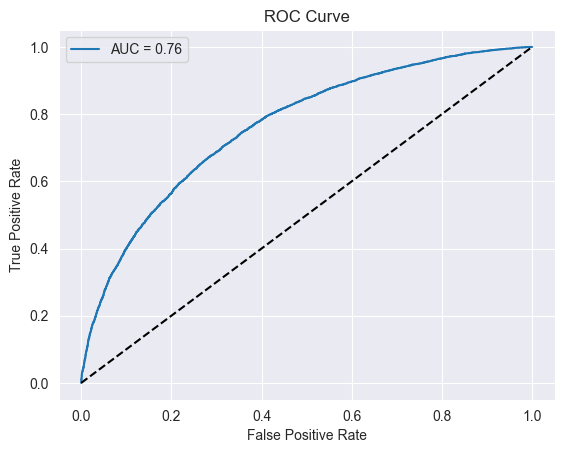

In [48]:
# ROC Curve
y_probs = best_model.predict_proba(df_test)[:, 1]
auc_score = roc_auc_score(y_test_class, y_probs)
print(f"AUC-ROC Score: {auc_score:.4f}")

# plot
fpr, tpr, _ = roc_curve(y_test_class, y_probs)
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
#Feature Importance
importances = best_model.feature_importances_

feature_names = df_train.columns.tolist()

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance_df

,Feature,Importance
8,bat_home_runs,0.163487
6,bat_doubles,0.105744
1,attendance,0.085131
14,salary,0.083193
2,temp,0.067737
...,...,...
45,LBV01,0.000000
40,HON01,0.000000
62,OMA01,0.000000
72,SEO01,0.000000
